What makes a London borough expensive?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f7",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": "sans-serif",
})

ACCENT   = "#1a6fc4"
ACCENT2  = "#d95f02"
ACCENT3  = "#1b9e77"
NEUTRAL  = "#7a7a78"


In [7]:
yearly  = pd.read_csv("housing_in_london_yearly_variables.csv")
monthly = pd.read_csv("housing_in_london_monthly_variables.csv")

yearly["date"]  = pd.to_datetime(yearly["date"])
monthly["date"] = pd.to_datetime(monthly["date"])

# Fix columns stored as strings with commas
yearly["mean_salary"]   = pd.to_numeric(yearly["mean_salary"].astype(str).str.replace(",", ""), errors="coerce")
yearly["recycling_pct"] = pd.to_numeric(yearly["recycling_pct"].astype(str).str.replace(",", ""), errors="coerce")

# Borough-only subsets (exclude Greater London aggregates)
yb = yearly[yearly["borough_flag"] == 1].copy()
mb = monthly[monthly["borough_flag"] == 1].copy()

print("Yearly dataset:  ", yearly.shape)
print("Monthly dataset: ", monthly.shape)
print("Boroughs in scope:", yb["area"].nunique())

Yearly dataset:   (1071, 12)
Monthly dataset:  (13549, 7)
Boroughs in scope: 33


In [8]:
YEARS = (2015, 2019)

price    = mb[mb["date"].dt.year.between(*YEARS)].groupby("area")["average_price"].mean()
crimes   = mb[mb["date"].dt.year.between(*YEARS)].groupby("area")["no_of_crimes"].mean()
salary   = yb[yb["date"].dt.year.between(*YEARS)].groupby("area")[["median_salary", "mean_salary"]].mean()
recycling= yb[yb["date"].dt.year.between(*YEARS)].groupby("area")["recycling_pct"].mean()
pop      = yb[yb["date"].dt.year.between(*YEARS)].groupby("area")["population_size"].mean()
jobs     = yb[yb["date"].dt.year.between(*YEARS)].groupby("area")["number_of_jobs"].mean()

df = (
    pd.DataFrame({"avg_price": price})
    .join(crimes)
    .join(salary)
    .join(recycling)
    .join(pop)
    .join(jobs)
)

# Price growth 1995 vs 2019
p1995 = mb[mb["date"].dt.year == 1995].groupby("area")["average_price"].mean()
p2019 = mb[mb["date"].dt.year == 2019].groupby("area")["average_price"].mean()
df["price_growth_pct"] = ((p2019 - p1995) / p1995 * 100)

df = df.dropna(subset=["avg_price", "median_salary"])
df.index = df.index.str.title()

print("\nBorough summary (first 5 rows):")
print(df.head())


Borough summary (first 5 rows):
                          avg_price  no_of_crimes  median_salary  mean_salary  \
area                                                                            
Barking And Dagenham  277921.100000   1533.700000   30259.600000      34287.6   
Barnet                519145.500000   2285.416667   31443.400000      36193.4   
Bexley                322321.616667   1233.300000   30679.666667      33672.8   
Brent                 477028.450000   2403.850000   30585.000000      35869.2   
Bromley               427203.733333   1883.216667   30471.500000      35539.0   

                      recycling_pct  population_size  number_of_jobs  \
area                                                                   
Barking And Dagenham          23.25        207787.00         64250.0   
Barnet                        36.50        386429.25        170750.0   
Bexley                        52.75        245071.00         87500.0   
Brent                         36.50    

In [9]:
predictors = {
    "number_of_jobs":  "Number of jobs",
    "mean_salary":     "Mean salary",
    "median_salary":   "Median salary",
    "no_of_crimes":    "Crime rate",
    "recycling_pct":   "Recycling rate",
    "population_size": "Population size",
}

correlations = {}
for col, label in predictors.items():
    valid = df[["avg_price", col]].dropna()
    r, p  = stats.pearsonr(valid["avg_price"], valid[col])
    correlations[label] = {"r": round(r, 3), "p": round(p, 4), "n": len(valid)}

corr_df = pd.DataFrame(correlations).T.sort_values("r", ascending=False)
print("\nCorrelations with average price:")
print(corr_df.to_string())


Correlations with average price:
                     r       p     n
Number of jobs   0.563  0.0006  33.0
Mean salary      0.428  0.0130  33.0
Median salary    0.423  0.0143  33.0
Crime rate       0.341  0.0559  32.0
Recycling rate  -0.329  0.0619  33.0
Population size -0.467  0.0062  33.0


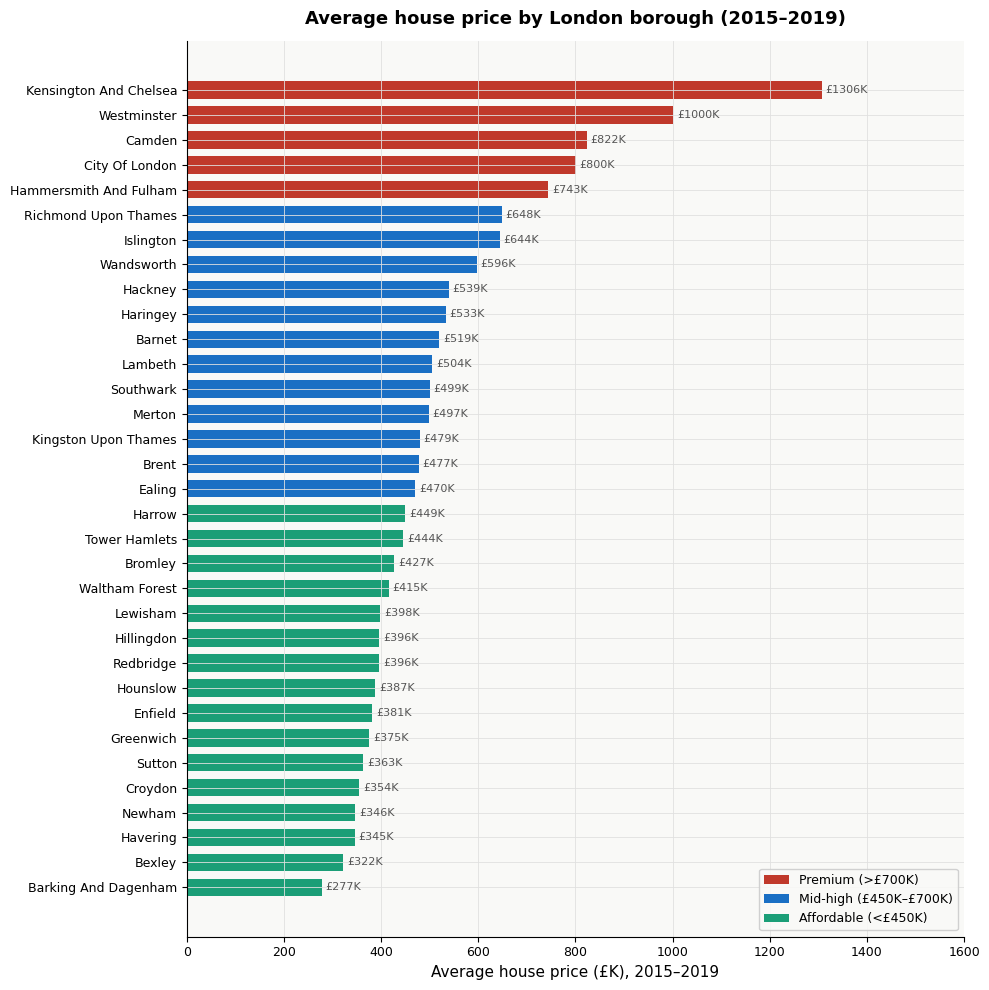

Saved: fig1_price_rankings.png


In [10]:
ranked = df["avg_price"].sort_values(ascending=True)

colors = []
for v in ranked:
    if v >= 700_000:
        colors.append("#c0392b")
    elif v >= 450_000:
        colors.append(ACCENT)
    else:
        colors.append(ACCENT3)

fig1, ax1 = plt.subplots(figsize=(10, 10))
bars = ax1.barh(ranked.index, ranked.values / 1000, color=colors, edgecolor="none", height=0.7)

ax1.set_xlabel("Average house price (£K), 2015–2019")
ax1.set_title("Average house price by London borough (2015–2019)", fontweight="bold", pad=12)

for bar, val in zip(bars, ranked.values):
    ax1.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
             f"£{int(val/1000)}K", va="center", fontsize=8, color="#555")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#c0392b", label="Premium (>£700K)"),
    Patch(facecolor=ACCENT,    label="Mid-high (£450K–£700K)"),
    Patch(facecolor=ACCENT3,   label="Affordable (<£450K)"),
]
ax1.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.9)
ax1.set_xlim(0, 1600)

fig1.tight_layout()
fig1.savefig("fig1_price_rankings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_price_rankings.png")


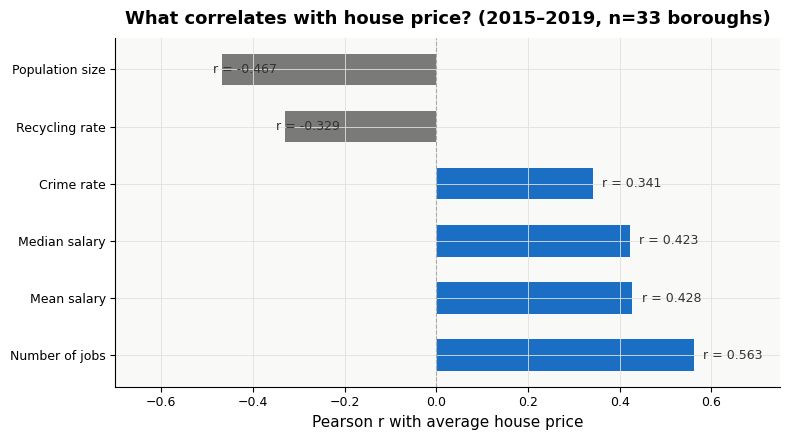

Saved: fig2_correlations.png


In [11]:
fig2, ax2 = plt.subplots(figsize=(8, 4.5))

bar_colors = [ACCENT if r >= 0 else NEUTRAL for r in corr_df["r"]]
bars2 = ax2.barh(corr_df.index, corr_df["r"], color=bar_colors, edgecolor="none", height=0.55)

ax2.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Pearson r with average house price")
ax2.set_title("What correlates with house price? (2015–2019, n=33 boroughs)", fontweight="bold", pad=10)
ax2.set_xlim(-0.7, 0.75)

for bar, (_, row) in zip(bars2, corr_df.iterrows()):
    x = bar.get_width()
    offset = 0.02 if x >= 0 else -0.02
    ha = "left" if x >= 0 else "right"
    ax2.text(x + offset, bar.get_y() + bar.get_height() / 2,
             f"r = {row['r']:.3f}", va="center", fontsize=9, color="#333")

fig2.tight_layout()
fig2.savefig("fig2_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_correlations.png")

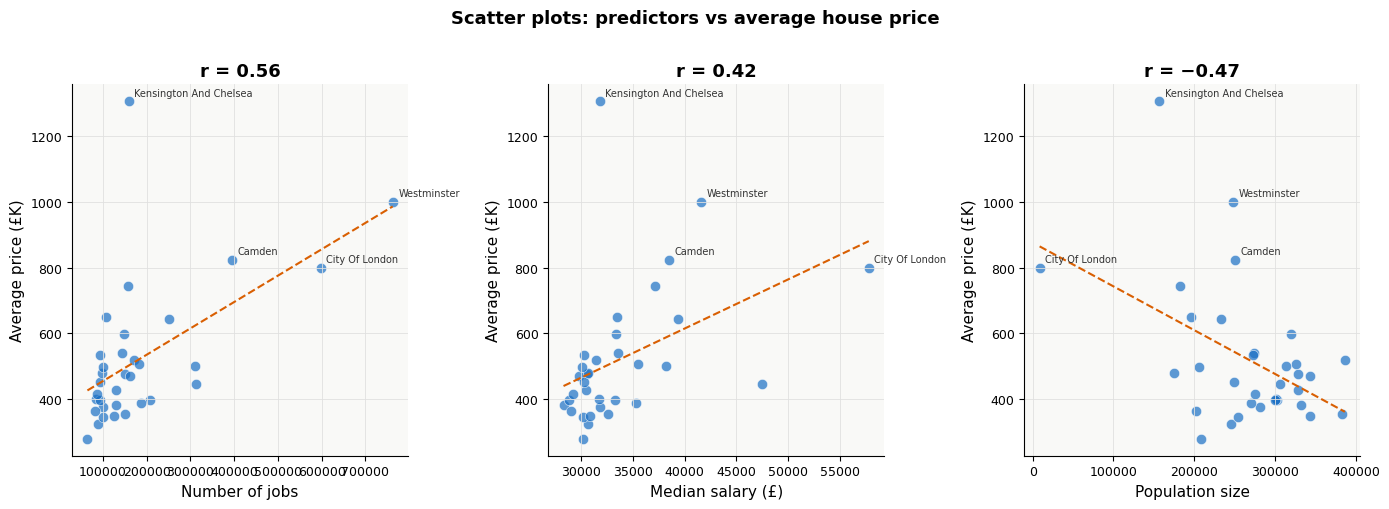

Saved: fig3_scatter_plots.png


In [12]:
scatter_vars = [
    ("number_of_jobs",  "Number of jobs",    "r = 0.56"),
    ("median_salary",   "Median salary (£)", "r = 0.42"),
    ("population_size", "Population size",   "r = −0.47"),
]

fig3, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, xlabel, r_label) in zip(axes, scatter_vars):
    subset = df[["avg_price", col]].dropna()
    x = subset[col]
    y = subset["avg_price"] / 1000

    ax.scatter(x, y, color=ACCENT, alpha=0.7, edgecolors="white", linewidths=0.5, s=55)

    # Regression line
    m, b, *_ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color=ACCENT2, linewidth=1.5, linestyle="--")

    # Label outliers (top 4 by price)
    top = subset.nlargest(4, "avg_price")
    for name, row in top.iterrows():
        ax.annotate(name, (row[col], row["avg_price"] / 1000),
                    fontsize=7, color="#333",
                    xytext=(4, 4), textcoords="offset points")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Average price (£K)")
    ax.set_title(r_label, fontweight="bold")

fig3.suptitle("Scatter plots: predictors vs average house price", fontsize=13, fontweight="bold", y=1.01)
fig3.tight_layout()
fig3.savefig("fig3_scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_scatter_plots.png")

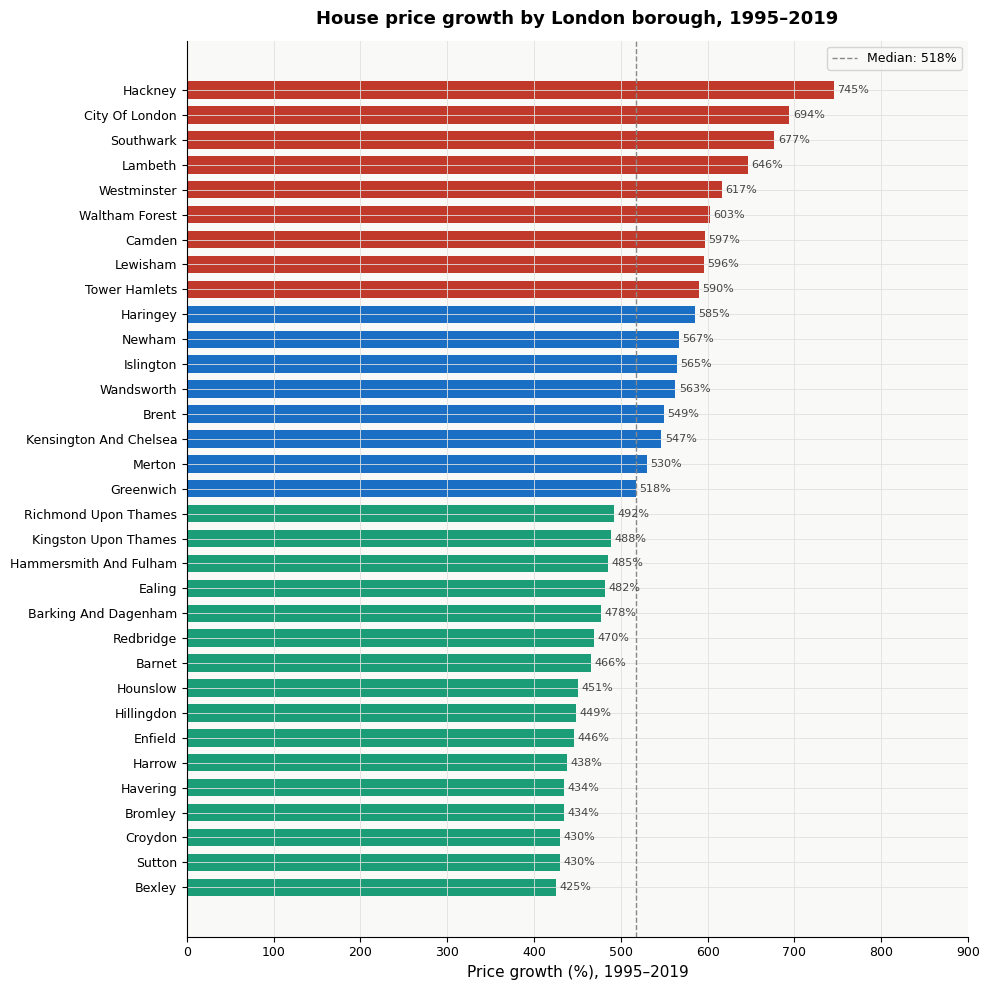

Saved: fig4_price_growth.png


In [13]:
growth = df["price_growth_pct"].dropna().sort_values(ascending=True)
q75 = growth.quantile(0.75)
q50 = growth.quantile(0.50)

grow_colors = []
for v in growth:
    if v >= q75:
        grow_colors.append("#c0392b")
    elif v >= q50:
        grow_colors.append(ACCENT)
    else:
        grow_colors.append(ACCENT3)

fig4, ax4 = plt.subplots(figsize=(10, 10))
ax4.barh(growth.index, growth.values, color=grow_colors, edgecolor="none", height=0.7)

ax4.set_xlabel("Price growth (%), 1995–2019")
ax4.set_title("House price growth by London borough, 1995–2019", fontweight="bold", pad=12)
ax4.axvline(growth.median(), color="#888", linewidth=1, linestyle="--", label=f"Median: {growth.median():.0f}%")
ax4.legend(fontsize=9)

for i, (name, val) in enumerate(growth.items()):
    ax4.text(val + 4, i, f"{val:.0f}%", va="center", fontsize=8, color="#444")

ax4.set_xlim(0, 900)

fig4.tight_layout()
fig4.savefig("fig4_price_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_price_growth.png")


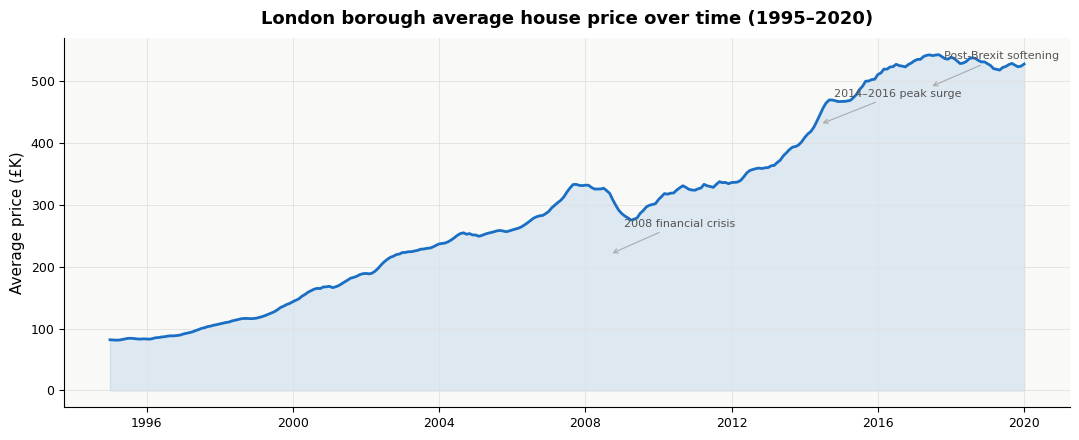

Saved: fig5_time_series.png


In [14]:
ts = mb.groupby("date")["average_price"].mean().reset_index()

fig5, ax5 = plt.subplots(figsize=(11, 4.5))
ax5.plot(ts["date"], ts["average_price"] / 1000, color=ACCENT, linewidth=2)
ax5.fill_between(ts["date"], ts["average_price"] / 1000, alpha=0.12, color=ACCENT)

# Annotate key events
events = {
    "2008 financial crisis": ("2008-09-01", 220),
    "2014–2016 peak surge":  ("2014-06-01", 430),
    "Post-Brexit softening": ("2017-06-01", 490),
}
for label, (date, y) in events.items():
    ax5.annotate(label, xy=(pd.Timestamp(date), y),
                 fontsize=8, color="#555",
                 arrowprops=dict(arrowstyle="->", color="#aaa", lw=0.8),
                 xytext=(10, 20), textcoords="offset points")

ax5.set_ylabel("Average price (£K)")
ax5.set_title("London borough average house price over time (1995–2020)", fontweight="bold", pad=10)

fig5.tight_layout()
fig5.savefig("fig5_time_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_time_series.png")

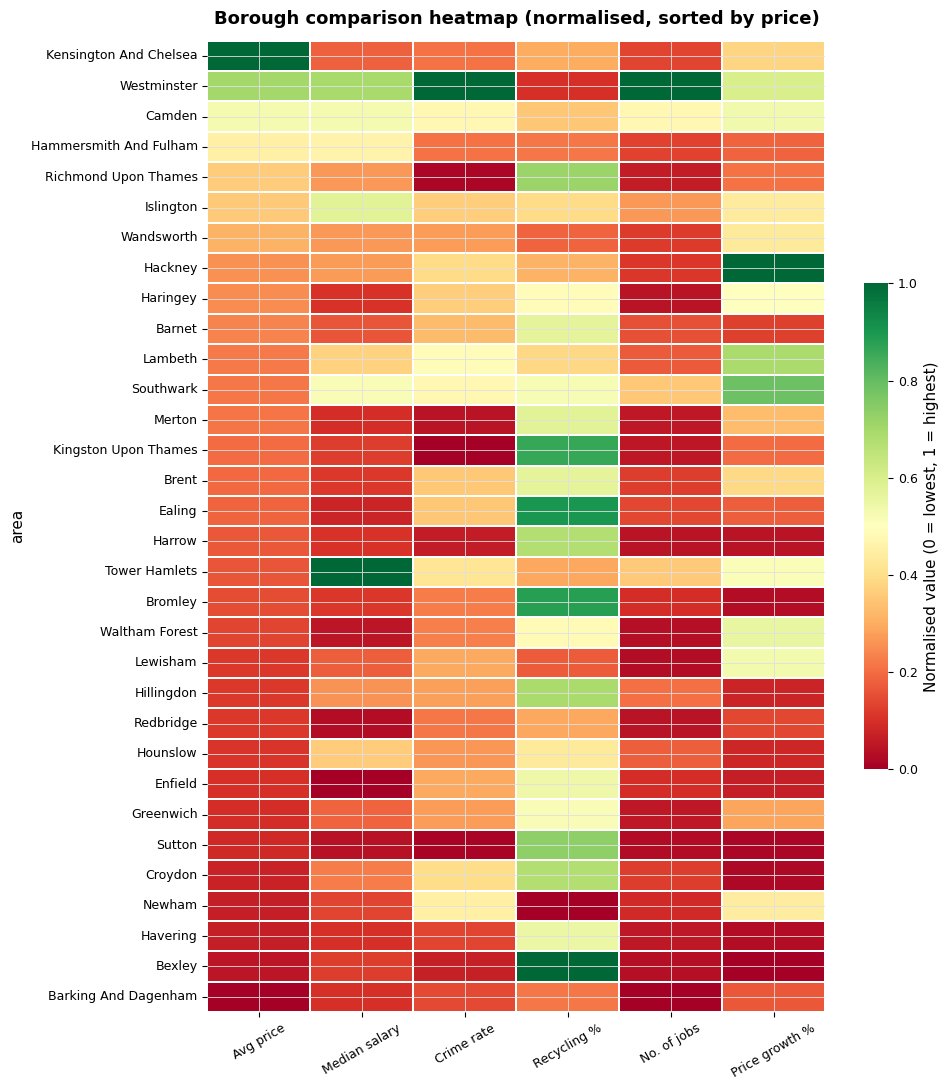

Saved: fig6_heatmap.png


In [15]:
heatmap_cols = {
    "avg_price":      "Avg price",
    "median_salary":  "Median salary",
    "no_of_crimes":   "Crime rate",
    "recycling_pct":  "Recycling %",
    "number_of_jobs": "No. of jobs",
    "price_growth_pct": "Price growth %",
}

hm = df[list(heatmap_cols.keys())].dropna().copy()
hm.columns = list(heatmap_cols.values())
hm_norm = (hm - hm.min()) / (hm.max() - hm.min())
hm_sorted = hm_norm.sort_values("Avg price", ascending=False)

fig6, ax6 = plt.subplots(figsize=(10, 11))
sns.heatmap(
    hm_sorted,
    ax=ax6,
    cmap="RdYlGn",
    linewidths=0.3,
    linecolor="white",
    annot=False,
    cbar_kws={"label": "Normalised value (0 = lowest, 1 = highest)", "shrink": 0.5},
)
ax6.set_title("Borough comparison heatmap (normalised, sorted by price)", fontweight="bold", pad=12)
ax6.set_xlabel("")
ax6.tick_params(axis="x", rotation=30)
ax6.tick_params(axis="y", rotation=0)

fig6.tight_layout()
fig6.savefig("fig6_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig6_heatmap.png")

In [16]:
summary = df[["avg_price", "median_salary", "no_of_crimes", "recycling_pct", "number_of_jobs"]].describe()
summary.index.name = "Statistic"
print("\n=== Borough summary statistics (2015–2019) ===")
print(summary.round(0).to_string())

top5    = df.nlargest(5, "avg_price")[["avg_price", "median_salary", "no_of_crimes"]]
bottom5 = df.nsmallest(5, "avg_price")[["avg_price", "median_salary", "no_of_crimes"]]

print("\n=== Top 5 most expensive boroughs ===")
print(top5.to_string())

print("\n=== Top 5 most affordable boroughs ===")
print(bottom5.to_string())

print("\nAnalysis complete. All figures saved to current directory.")


=== Borough summary statistics (2015–2019) ===
           avg_price  median_salary  no_of_crimes  recycling_pct  number_of_jobs
Statistic                                                                       
count           33.0           33.0          32.0           33.0            33.0
mean        520194.0        33766.0        2121.0           33.0        182318.0
std         213542.0         6005.0         793.0            9.0        149749.0
min         277921.0        28356.0         959.0           15.0         64250.0
25%         387457.0        30304.0        1743.0           26.0         97500.0
50%         470399.0        31749.0        2096.0           34.0        142500.0
75%         539240.0        35299.0        2485.0           40.0        182000.0
max        1306776.0        57731.0        5042.0           53.0        762500.0

=== Top 5 most expensive boroughs ===
                           avg_price  median_salary  no_of_crimes
area                                 

# What Makes a London Borough Expensive? — EDA Summary

## Dataset overview
This analysis draws on two datasets covering all 33 London boroughs:
- **Monthly data** (1995–2020): average house prices, houses sold, and recorded crime
- **Yearly data** (1999–2019): median and mean salary, population, number of jobs, recycling rate, and area size

Borough-level averages for 2015–2019 were used as the primary comparison window, with the full time series retained for trend analysis.

---

## Key findings

### 1. Employment density is the strongest predictor of price (r = 0.56)
The number of jobs located within a borough correlates more strongly with average house prices than any other variable in the dataset. Boroughs with large employment bases — Westminster (~580,000 jobs), the City of London (~490,000), and Tower Hamlets (~280,000) — consistently command the highest prices. This suggests that housing demand in London is driven more by proximity to employment than by the characteristics of residents themselves.

### 2. Resident salary explains surprisingly little (r = 0.42)
Median and mean salary show a moderate positive correlation with price, but numerous boroughs break this relationship. Kensington & Chelsea has a median resident salary of approximately £31,800 — unremarkable by London standards — yet records the highest average house price (~£1.31M). Conversely, Tower Hamlets has one of the highest median salaries (~£47,500, driven by Canary Wharf workers) but sits mid-table on price. Prestige, international investment, and historic desirability appear to operate independently of what residents earn.

### 3. Smaller populations are associated with higher prices (r = −0.47)
Inner London's more compact boroughs consistently carry price premiums over larger outer boroughs. This reflects the value placed on centrality and proximity rather than anything intrinsic to the housing stock.

### 4. The crime paradox (r = 0.34)
Higher recorded crime is weakly associated with higher prices — an apparent contradiction explained by confounding. The most expensive and most active boroughs (Westminster, Camden, Lambeth) generate the highest footfall and therefore the highest crime counts. Crime here is a proxy for urban density rather than a marker of deprivation.

### 5. Recycling rate is a negative signal (r = −0.33)
More affordable outer boroughs tend to have higher recycling rates. This variable effectively functions as an inner/outer London proxy rather than a direct driver of price.

---

## Price growth: 1995–2019
Every London borough more than quadrupled in nominal house price over this period. The most striking growth occurred in formerly working-class inner boroughs that underwent significant gentrification:

| Borough | Growth (%) |
|---|---|
| Hackney | +745% |
| City of London | +694% |
| Southwark | +677% |
| Lambeth | +646% |
| Westminster | +617% |

Historically expensive boroughs such as Kensington & Chelsea (+547%) grew more slowly, reflecting a higher starting base. The most affordable boroughs — Bexley, Sutton, Croydon — saw the smallest relative increases, suggesting that the gap between inner and outer London has widened substantially over this period.

---

## Limitations
- The `life_satisfaction` variable was excluded due to ~67% missing values across the dataset.
- Crime data is absent for the City of London in several years, limiting its inclusion in correlation analysis.
- Salary data reflects *resident* earnings, not the earnings of those who work in a borough — a meaningful distinction for employment hubs like the City and Canary Wharf.
- All monetary figures are nominal and have not been adjusted for inflation.
- Correlations are cross-sectional and cannot establish causation.

---

## Conclusion
London house prices are shaped primarily by a borough's position within the city's employment geography, reinforced by prestige and historic investment. Resident income and borough-level characteristics play a secondary role. The data indicate that affordability in London is fundamentally a question of distance from where the economic activity is concentrated, and that this premium has compounded significantly since 1995.